In [72]:
import pandas as pd
import numpy as np
from scipy.linalg import norm
from scipy.linalg import eigh as eig
import plotly_express as px
import seaborn as sns
import os
from matplotlib import pyplot as plt

sns.set(style='ticks')

F1_path = 'data/F1'
F4_path = 'data/F4'
F5_path = 'data/F5'
os.makedirs(F5_path, exist_ok=True)
os.makedirs(f"{F5_path}/PCA", exist_ok = True)


OHCO = ['work_id','part_num','chap_num','para_num','sent_num','token_num']
PARAS = OHCO[:4]
WORKS = OHCO[:1]

## Load F4 Data

In [73]:
LIB = pd.read_csv(f"{F1_path}/LIB.csv", index_col = OHCO[0])
VOCAB = pd.read_csv(f"{F4_path}/VOCAB.csv", index_col = 'term_id', keep_default_na=False, na_values=[])
BOW_PARA = pd.read_csv(f"{F4_path}/BOW_PARA.csv", index_col = PARAS + ['term_id'], keep_default_na=False, na_values=[])
BOW_WORK = pd.read_csv(f"{F4_path}/BOW_WORK.csv", index_col = WORKS + ['term_id'], keep_default_na=False, na_values=[])

print(f"LIB: {len(LIB)} works")
print(f"VOCAB: {len(VOCAB)} terms")
print(f"BOW_PARA: {len(BOW_PARA)} (paragraph, term) rows)")

LIB: 49 works
VOCAB: 15393 terms
BOW_PARA: 188023 (paragraph, term) rows)


## Reduce VOCAB to significant terms

In [74]:
SIGS = (VOCAB[(VOCAB.stop == 0) & (VOCAB.n >= 5)] #removes stopwords and rare words
        .sort_values('tfidf_sum', ascending=False) #sorts by tfidf sum
        .head(5000)) #pick the top 5000 words

sig_term_ids = SIGS.index.tolist()

print(f"Signficant terms: {len(SIGS):,}")
SIGS[['term_str','n','pos_max','tfidf_sum']].head(10)

Signficant terms: 4,540


,term_str,n,pos_max,tfidf_sum
term_id,,,,
13824,thy,60,NNP,0.087182
8729,miss,589,NNP,0.081802
9093,neverout,391,JJ,0.052392
13014,stella,19,NNP,0.043144
7746,lady,429,JJ,0.039200
8451,martin,47,NNP,0.038039
12572,smart,316,NNP,0.035021
13685,thee,32,NNP,0.033753
2560,col,203,JJ,0.030919


## PCA Function

In [75]:
def run_pca(TFIDF, vocab, n_components=10):
    # L2 normalize doc vectors
    TFIDF = TFIDF.apply(lambda x: x/norm(x),1).dropna(how='all')

    # Covariance and eigendecomposition
    COV = TFIDF.cov()
    eig_vals, eig_vecs = eig(COV)
    TERM_IDX = COV.index

    # wrap eigendata in DFs
    EIG_VEC = pd.DataFrame(eig_vecs, index = TERM_IDX, columns = TERM_IDX)
    EIG_VAL = pd.DataFrame(eig_vals, index = TERM_IDX, columns = ['eig_val'])
    EIG_PAIRS = EIG_VAL.join(EIG_VEC.T)
    EIG_PAIRS['exp_var'] = np.round((EIG_PAIRS.eig_val / EIG_PAIRS.eig_val.sum()) * 100, 2)

    # pick top N components
    TOPS = EIG_PAIRS.sort_values('exp_var', ascending=False).head(n_components).reset_index(drop=True)
    TOPS.index.name = 'comp_id'
    TOPS.index = ['PC{}'.format(i) for i in TOPS.index.tolist()]

    # build loadings
    LOADINGS = TOPS[TERM_IDX].T
    LOADINGS.index.name = 'term_id'
    LOADINGS['term_str'] = LOADINGS.apply(lambda x: vocab.loc[int(x.name)].term_str, 1)

    # project documents
    DCM = TFIDF.dot(TOPS[TERM_IDX].T)

    return TOPS, LOADINGS, DCM, TFIDF

## Helpers for inspecting and visualizing

In [112]:
def show_loadings(LOADINGS, components=None, n=10):
    if components is None:
        components = ['PC0','PC1','PC2','PC3','PC4']
    for pc in components:
        pos = LOADINGS.sort_values(pc, ascending = True).head(n).term_str.str.cat(sep = ' ')
        neg = LOADINGS.sort_values(pc, ascending = False).head(n).term_str.str.cat(sep=' ')
        print(f'{pc}+ {pos}')
        print(f'{pc}- {neg}')
        print()

def attach_metadata(DCM, work_level=False):
    if work_level:
        DCM['label'] = LIB.broad_genre
        DCM['title'] = LIB.title
        DCM['genre'] = LIB.genre
    else:
        DCM['label'] = DCM.apply(lambda x: LIB.broad_genre[x.name[0]], 1)
        DCM['title'] = DCM.apply(lambda x: LIB.title[x.name[0]], 1)
        DCM['genre'] = DCM.apply(lambda x: LIB.genre[x.name[0]], 1)
    return DCM

def vis_pcs(M, a, b, prefix='PC'):
    fig = px.scatter(M, prefix+str(a), prefix+str(b),
                     color='label',
                     hover_name='title',
                     marginal_x='box')
    fig.update_layout(width=700, height=600)
    fig.update_yaxes(scaleanchor='x', scaleratio=1)
    fig.show()

def vis_pcs_static(M,a,b,prefix = 'PC',figsize = (10,7), title=None, save_path = None):
    fig, ax = plt.subplots(figsize = figsize)
    colors = {"Satire":"red",
              "Political":"green",
              "Verse":"blue",
              "Religious":"purple",
              "Essay":"orange"}
    for label, group in M.groupby('label'):
        ax.scatter(group[f'{prefix}{a}'], group[f'{prefix}{b}'],
                         label=label, alpha = 0.6, s = 30,
                         color = colors.get(label,'gray'))
    ax.set_xlabel(f'{prefix}{a}', fontsize = 12)
    ax.set_ylabel(f'{prefix}{b}', fontsize = 12)
    if title:
        ax.set_title(title, fontsize=13)
    ax.legend(bbox_to_anchor=(1.02,1), loc = 'upper left', fontsize = 10, frameon=True, edgecolor='lightgray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha = 0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

## PCA (first run)

In [77]:
BOW_SIG_pa = BOW_PARA[BOW_PARA.index.get_level_values('term_id').isin(sig_term_ids)]
TFIDF_pa = BOW_SIG_pa['tfidf'].unstack(fill_value=0)
print(f"TFIDF_pa: {TFIDF_pa.shape}")

TFIDF_pa: (3558, 4540)


In [78]:
TOPS_pa, LOADINGS_pa, DCM_pa, TFIDF_pa = run_pca(TFIDF_pa, VOCAB)

In [79]:
TOPS_pa[['eig_val','exp_var']]

,eig_val,exp_var
PC0,0.013608,1.38
PC1,0.011317,1.15
PC2,0.008988,0.91
PC3,0.008094,0.82
PC4,0.007030,0.71
PC5,0.006504,0.66
PC6,0.005494,0.56
PC7,0.005283,0.54
PC8,0.005136,0.52
PC9,0.004588,0.47


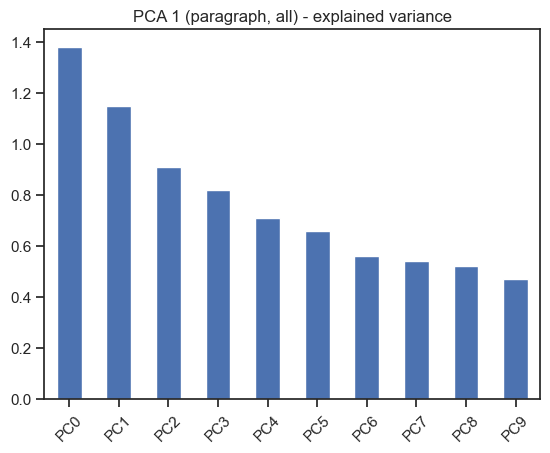

In [80]:
TOPS_pa.exp_var.plot.bar(rot=45, title = 'PCA 1 (paragraph, all) - explained variance')
plt.show()

### Loadings

In [110]:
print("PCA 1:")
show_loadings(LOADINGS_pa)

PCA 1:
PC0+ upon would great could country many people several every men
PC0- miss lady smart neverout pray ld answ colonel mr sir

PC1+ lady smart ld sir john sparkish answ colonel ay say
PC1- miss neverout mr col ill dont im faith well tell

PC2+ lady answ smart mr neverout colonel among shall upon would
PC2- ld sparkish sir john col madam tom pray lord ladyship

PC3+ sparkish ld tom colonel madam ladyship pray ay mrs hes
PC3- sir john neverout col thank ill wont darbyshire pipe faith

PC4+ neverout mr ld sparkish smart sir john colonel come take
PC4- col miss lord madam answ pray ladyship say tom lady



Pretty much every component is about Polite Conversation, which makes sense because it contributes a major portion of the paragraphs with a very distinctive vocabulary of character names, dialogue tags, etc.

### Scatter

In [82]:
DCM_pa = attach_metadata(DCM_pa)

In [113]:
vis_pcs(DCM_pa, 0, 1)

In [114]:
vis_pcs(DCM_pa, 1, 2)

## PCA (second run)
Since we've seen that Polite Conversation dominates the components, let's exclude it and re-run. This should reveal the structure of variation across Swift's other writings.

In [85]:
pc_ids = LIB[LIB.title.str.contains('Polite', case=False)].index.tolist()

print(f"Excluding {len(pc_ids)} works:")
for w in pc_ids:
    print(f"    {w}: {LIB.loc[w, 'title']}")

Excluding 4 works:
    polite_conversation_intro: Polite Conversation: Introduction
    polite_conversation_dialogue_1: Polite Conversation: Dialogue I
    polite_conversation_dialogue_2: Polite Conversation: Dialogue II
    polite_conversation_dialogue_3: Polite Conversation: Dialogue III


In [86]:
BOW_SIG_px = BOW_PARA[
    BOW_PARA.index.get_level_values('term_id').isin(sig_term_ids) &
    (~BOW_PARA.index.get_level_values('work_id').isin(pc_ids))
]
TFIDF_px = BOW_SIG_px['tfidf'].unstack(fill_value=0)
print(f"TFIDF_px: {TFIDF_px.shape}")

TFIDF_px: (1964, 4512)


In [87]:
TOPS_px, LOADINGS_px, DCM_px, TFIDF_px = run_pca(TFIDF_px, VOCAB)

In [88]:
TOPS_px[['eig_val','exp_var']]

,eig_val,exp_var
PC0,0.006161,0.63
PC1,0.004741,0.48
PC2,0.004500,0.46
PC3,0.004217,0.43
PC4,0.003296,0.34
PC5,0.003281,0.33
PC6,0.003198,0.33
PC7,0.003110,0.32
PC8,0.002956,0.30
PC9,0.002842,0.29


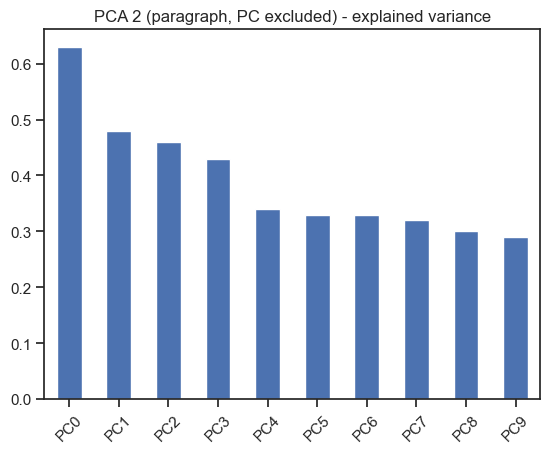

In [89]:
TOPS_px.exp_var.plot.bar(rot=45, title='PCA 2 (paragraph, PC excluded) - explained variance')
plt.show()

### Loadings

In [109]:
print("PCA 2:")
show_loadings(LOADINGS_px)

PCA 2:
PC0+ letter 1724 written sir author ireland lord ii irish est
PC0- could would upon one two much made might came time

PC1+ ireland kingdom wood halfpence england us people patent may coin
PC1- letter could feet took master 1724 came three island gave

PC2+ men wisdom hath among virtue man world wit preaching shall
PC2- letter ireland wood halfpence kingdom england pounds hundred patent coin

PC3+ 1724 england irish ireland pounds proposal thousand three manufactures hundred
PC3- letter men may upon among first world us hath written

PC4+ author ireland england irish proposal country lord king houyhnhnms manufactures
PC4- 1724 written thousand pounds hundred year august old october may



### Scatter

In [91]:
DCM_px = attach_metadata(DCM_px)

In [115]:
vis_pcs(DCM_px, 0, 1)

In [116]:
vis_pcs(DCM_px, 1, 2)

In [117]:
vis_pcs(DCM_px, 2, 3)

## PCA (third run)
A third run at the work-level, with all 49 works. Aggregating to the work level means each document carries equal weight in the PCA. Polite Conversation contributes one point rather than 1,510.

In [95]:
BOW_SIG_w= BOW_WORK[BOW_WORK.index.get_level_values('term_id').isin(sig_term_ids)]
TFIDF_w = BOW_SIG_w['tfidf'].unstack(fill_value=0)
print(f"TFIDF_w: {TFIDF_w.shape}")

TFIDF_w: (49, 4540)


In [96]:
TOPS_w, LOADINGS_w, DCM_w, TFIDF_w = run_pca(TFIDF_w, VOCAB)

In [97]:
TOPS_w[['eig_val','exp_var']]

,eig_val,exp_var
PC0,0.065802,7.22
PC1,0.054469,5.98
PC2,0.046134,5.06
PC3,0.037339,4.10
PC4,0.033452,3.67
PC5,0.028581,3.14
PC6,0.024864,2.73
PC7,0.024107,2.65
PC8,0.023619,2.59
PC9,0.022607,2.48


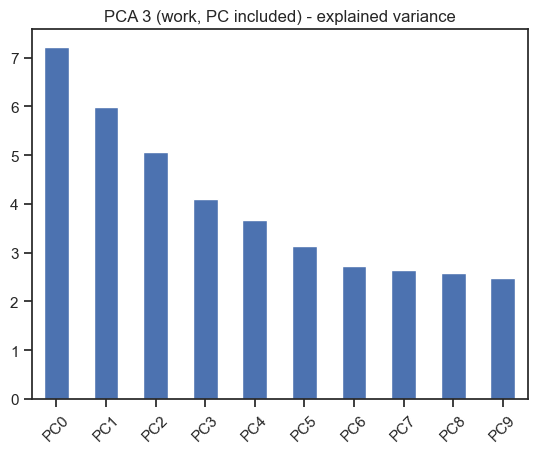

In [98]:
TOPS_w.exp_var.plot.bar(rot=45, title='PCA 3 (work, PC included) - explained variance')
plt.show()

### Loadings

In [111]:
print("PCA 3:")
show_loadings(LOADINGS_w)

PCA 3:
PC0+ kingdom halfpence ireland wood mr patent woods england coin money
PC0- thy miss neverout thee lady smart col stella ld answ

PC1+ miss neverout lady smart col ld answ madam colonel john
PC1- thy thee thou beseech accept repentance prayers stella hath behalf

PC2+ martin stella stellas peter christianity jack neer wit dean though
PC2- thy wood halfpence thee miss mr patent ireland woods kingdom

PC3+ miss thy hath conversation neverout christianity thee company smart lady
PC3- stella stellas halfpence wood dean patent woods mr martin coin

PC4+ stella stellas nymph wit neer dean virtue quit face vanessa
PC4- martin peter jack landlord peters martins harry jacks salves powders



### Scatter

In [100]:
DCM_w = attach_metadata(DCM_w, work_level = True)

In [118]:
vis_pcs(DCM_w, 0, 1)

In [119]:
vis_pcs(DCM_w, 1, 2)

In [103]:
vis_pcs(DCM_w, 2, 3)

## Static graphs for report

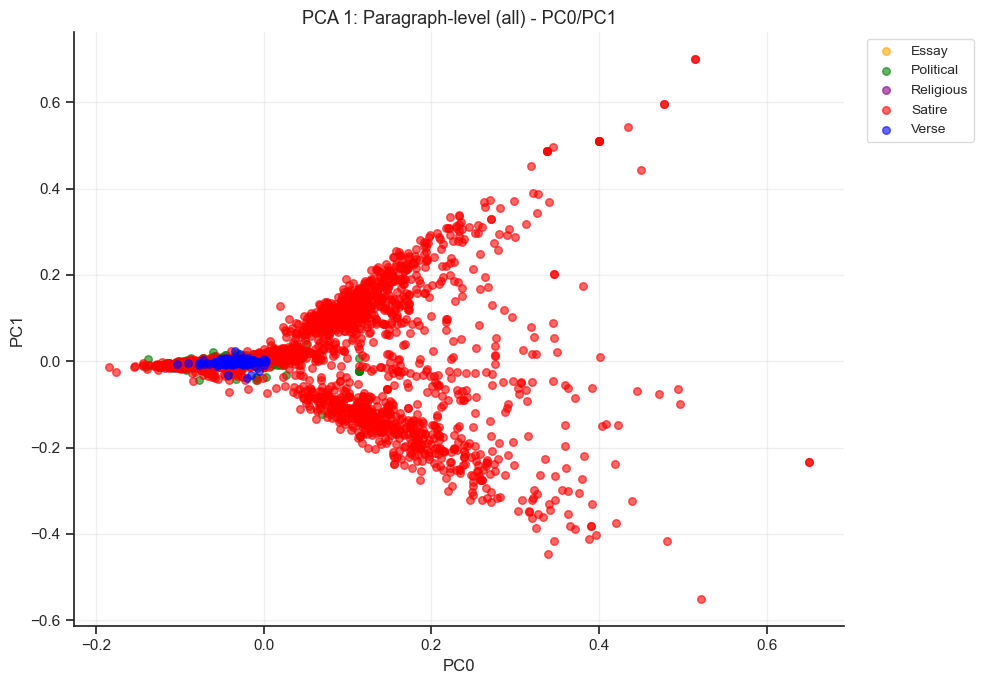

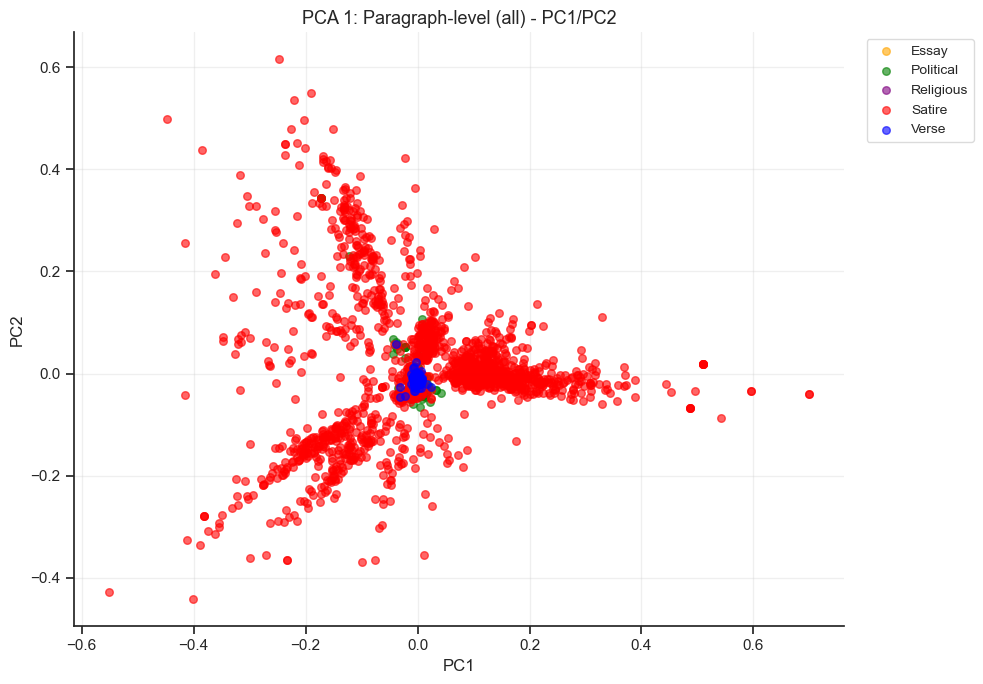

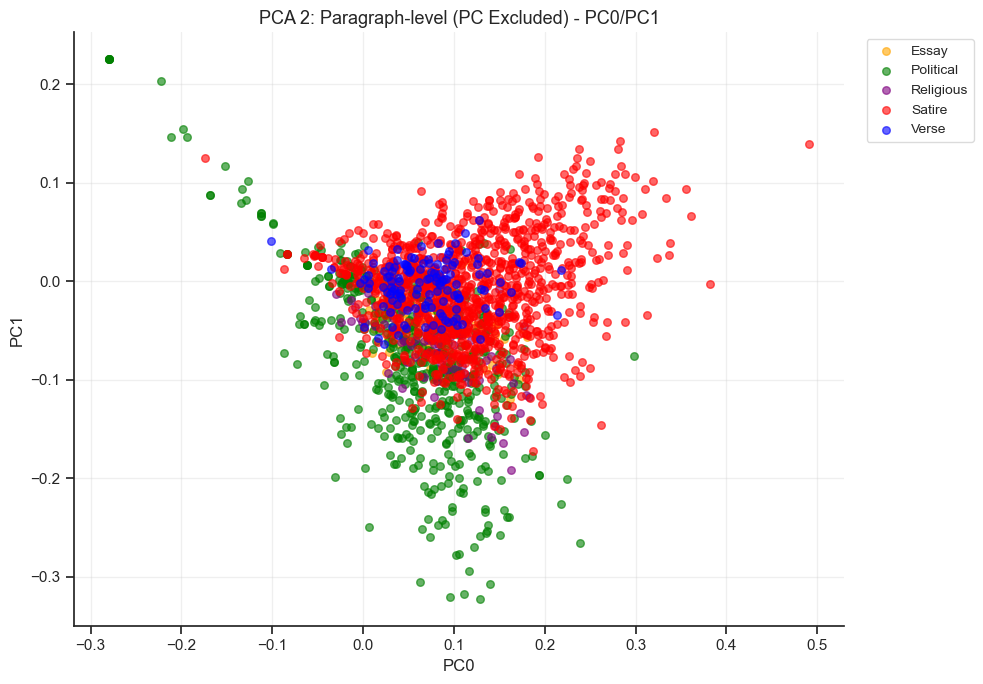

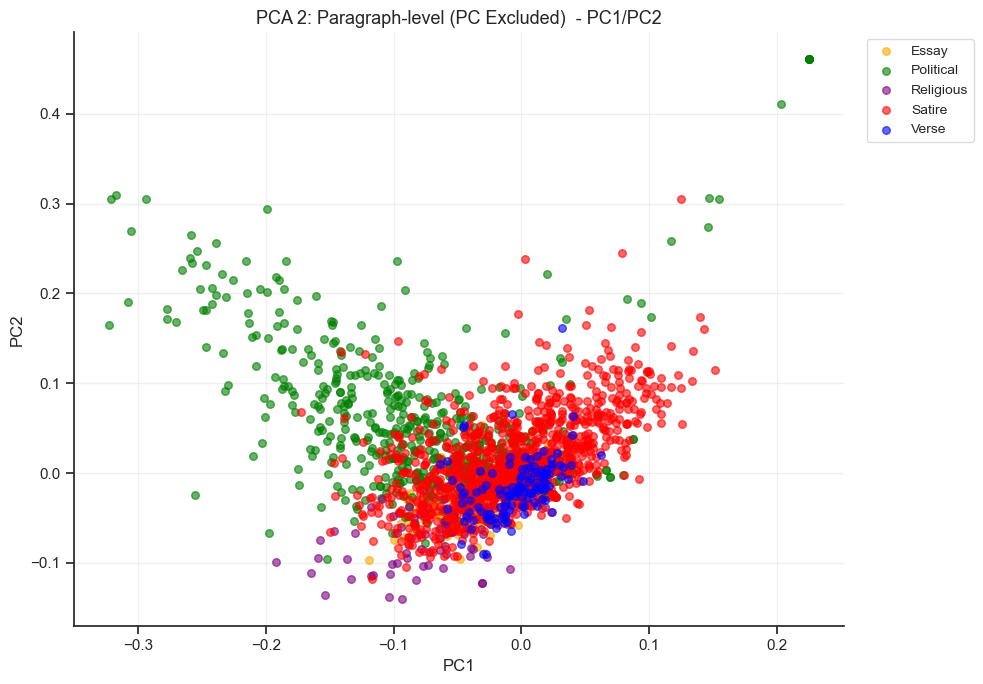

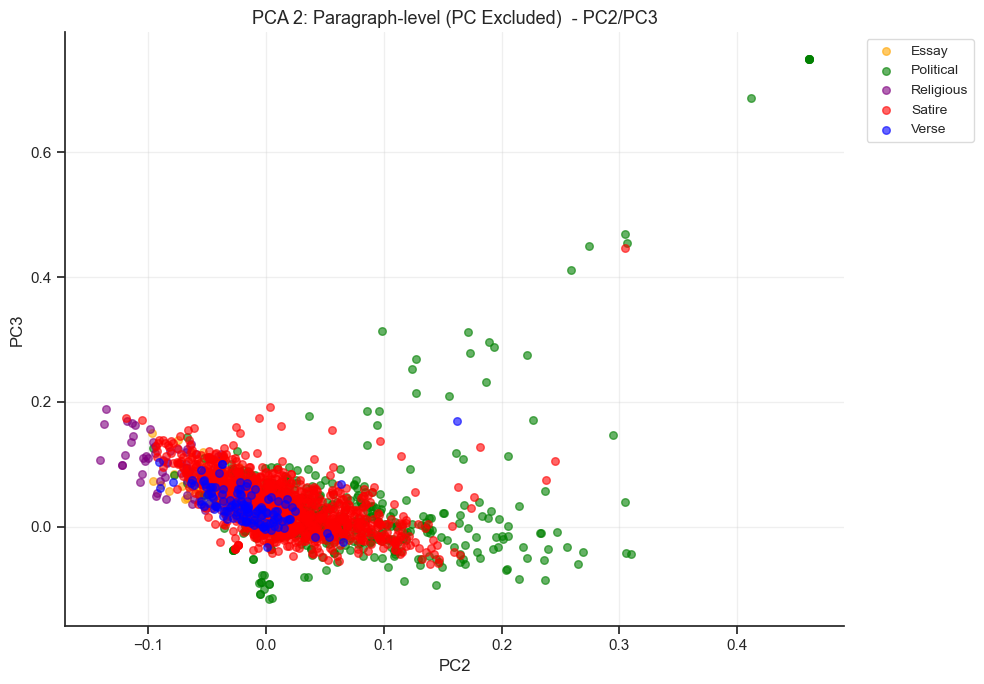

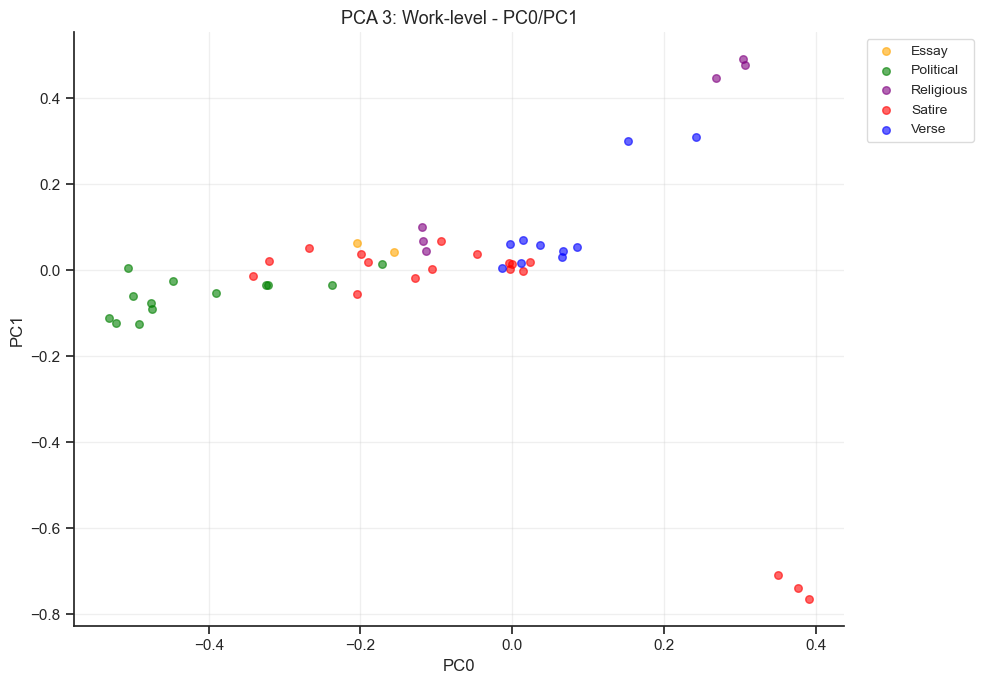

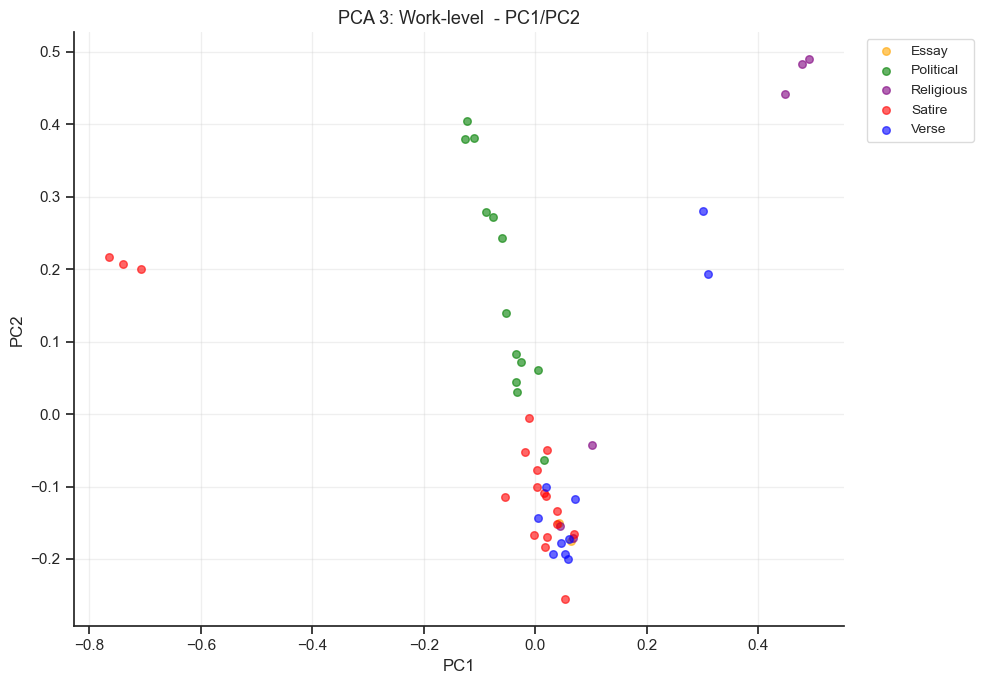

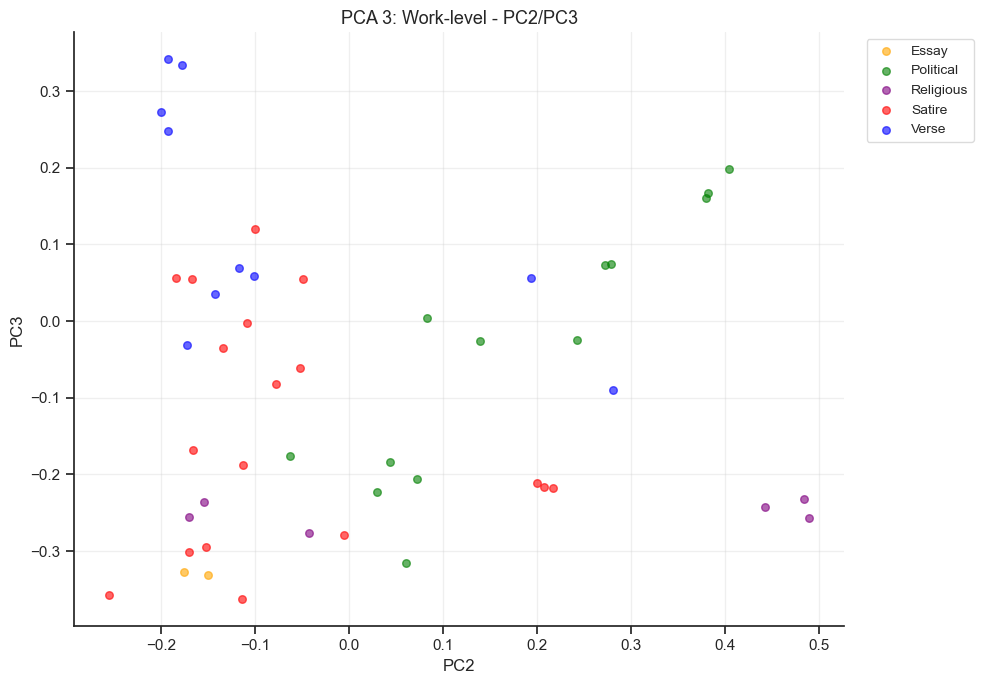

In [108]:
os.makedirs(f"{F5_path}/PCA/figures", exist_ok = True)

vis_pcs_static(DCM_pa, 0, 1, title = 'PCA 1: Paragraph-level (all) - PC0/PC1',
               save_path = f"{F5_path}/PCA/figures/pca_para_all_pc01.png")
vis_pcs_static(DCM_pa, 1, 2, title = 'PCA 1: Paragraph-level (all) - PC1/PC2',
               save_path = f"{F5_path}/PCA/figures/pca_para_all_pc12.png")

vis_pcs_static(DCM_px, 0, 1, title = 'PCA 2: Paragraph-level (PC Excluded) - PC0/PC1',
               save_path = f"{F5_path}/PCA/figures/pca_para_nopc_pc01.png")
vis_pcs_static(DCM_px, 1, 2, title = 'PCA 2: Paragraph-level (PC Excluded)  - PC1/PC2',
               save_path = f"{F5_path}/PCA/figures/pca_para_nopc_pc12.png")
vis_pcs_static(DCM_px, 2, 3, title = 'PCA 2: Paragraph-level (PC Excluded)  - PC2/PC3',
               save_path = f"{F5_path}/PCA/figures/pca_para_nopc_pc23.png")

vis_pcs_static(DCM_w, 0, 1, title = 'PCA 3: Work-level - PC0/PC1',
               save_path = f"{F5_path}/PCA/figures/pca_work_pc01.png")
vis_pcs_static(DCM_w, 1, 2, title = 'PCA 3: Work-level  - PC1/PC2',
               save_path = f"{F5_path}/PCA/figures/pca_work_pc12.png")
vis_pcs_static(DCM_w, 2, 3, title = 'PCA 3: Work-level - PC2/PC3',
               save_path = f"{F5_path}/PCA/figures/pca_work_pc23.png")

## Save

In [106]:
os.makedirs(f"{F5_path}/PCA", exist_ok = True)

DCM_pa.to_csv(f"{F5_path}/PCA/PCA_DCM_para_all.csv")
LOADINGS_pa.to_csv(f"{F5_path}/PCA/PCA_LOADINGS_para_all.csv")

DCM_px.to_csv(f"{F5_path}/PCA/PCA_DCM_para_no_polite.csv")
LOADINGS_px.to_csv(f"{F5_path}/PCA/PCA_LOADINGS_para_no_polite.csv")

DCM_w.to_csv(f"{F5_path}/PCA/PCA_DCM_work.csv")
LOADINGS_w.to_csv(f"{F5_path}/PCA/PCA_LOADINGS_work.csv")

SIGS.to_csv(f"{F5_path}/PCA/SIGS.csv") 